In [1]:
import pandas as pd
import numpy as np

print("Halo! Pandas dan NumPy siap digunakan.")

Halo! Pandas dan NumPy siap digunakan.


In [4]:
import pandas as pd

# Ganti 'nama_file_kamu.csv' dengan nama persis file CSV yang kamu unduh tadi
df = pd.read_csv('SampleSuperstore.csv')

# Menampilkan 5 baris pertama dari data
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1.7 MB


In [7]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Penjualan Keseluruhan: ${total_sales:,.2f}")
print(f"Total Keuntungan Keseluruhan: ${total_profit:,.2f}")

Total Penjualan Keseluruhan: $2,297,200.86
Total Keuntungan Keseluruhan: $286,397.02


In [8]:
df.groupby('Category')['Sales'].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

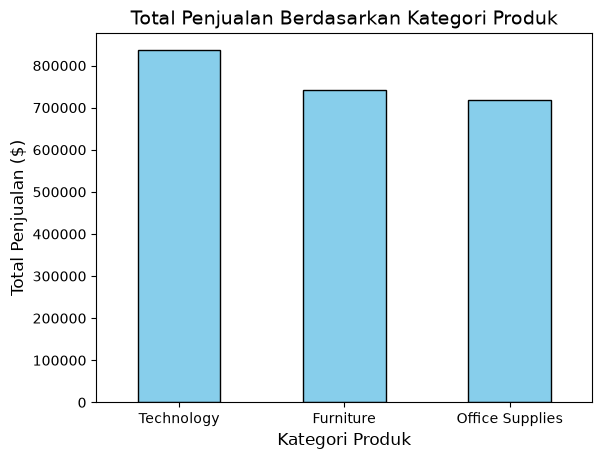

In [9]:
# Membuat grafik total penjualan berdasarkan kategori produk
df.groupby('Category')['Sales'].sum().sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black')

# Menambahkan judul dan label agar terlihat profesional
import matplotlib.pyplot as plt
plt.title('Total Penjualan Berdasarkan Kategori Produk', fontsize=14)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Total Penjualan ($)', fontsize=12)
plt.xticks(rotation=0)
plt.show()

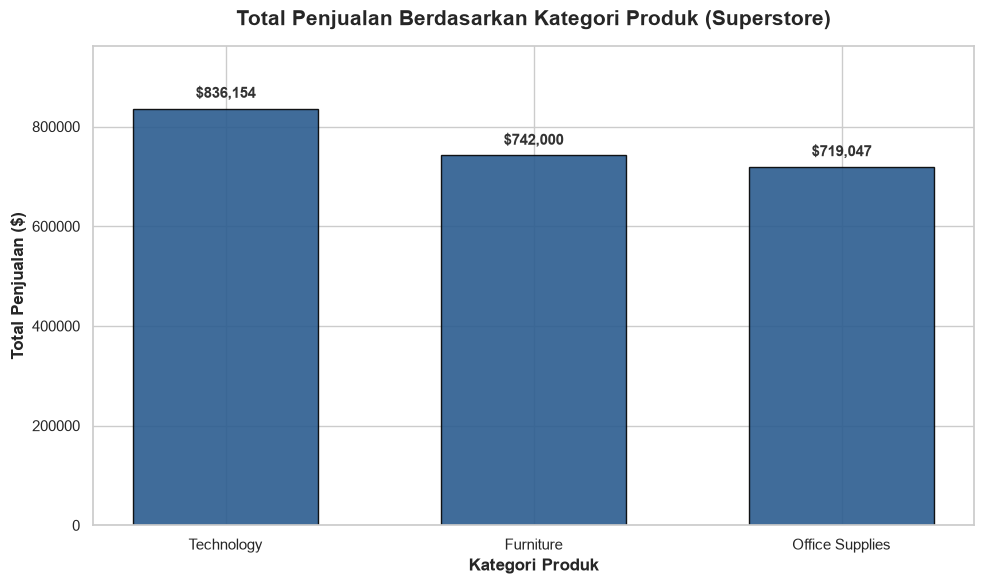

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visual agar terlihat modern (clean & professional)
sns.set_theme(style="whitegrid")

# Menyiapkan data
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Mengatur ukuran kanvas grafik
plt.figure(figsize=(10, 6))

# Membuat grafik batang dengan warna profesional
bars = plt.bar(sales_category.index, sales_category.values, color='#2b5c8f', width=0.6, edgecolor='black', alpha=0.9)

# Menambahkan label angka di atas setiap batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 15000, f"${yval:,.0f}", 
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='#333333')

# Menambahkan judul, label sumbu, dan mempercantik tampilan
plt.title('Total Penjualan Berdasarkan Kategori Produk (Superstore)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Kategori Produk', fontsize=12, fontweight='bold')
plt.ylabel('Total Penjualan ($)', fontsize=12, fontweight='bold')
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Menyesuaikan batas atas sumbu Y agar label angka tidak terpotong
plt.ylim(0, max(sales_category.values) * 1.15)

# Menampilkan grafik
plt.tight_layout()
plt.show()

In [11]:
# Melihat 5 Sub-Kategori dengan Profit Tertinggi dan Terendah
top_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print("--- 5 Sub-Kategori Profit Tertinggi ---")
print(top_profit.head())
print("\n--- 5 Sub-Kategori Profit Terendah/Rugi ---")
print(top_profit.tail())

--- 5 Sub-Kategori Profit Tertinggi ---
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64

--- 5 Sub-Kategori Profit Terendah/Rugi ---
Sub-Category
Machines      3384.7569
Fasteners      949.5182
Supplies     -1189.0995
Bookcases    -3472.5560
Tables      -17725.4811
Name: Profit, dtype: float64


In [17]:
# Melihat rata-rata profit berdasarkan besar kecilnya diskon
discount_analysis = df.groupby('Discount')['Profit'].mean()
print(discount_analysis)

Discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: Profit, dtype: float64
